# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Geopolitical Energy Shock Dataset](https://www.kaggle.com/datasets/rahuldata1/geopolitical-energy-shock-analytics-20222026)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('Geopolitical_Energy_Shock_Global_Market_Impact_2022_2026.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,date,country,oil_price,oil_change_pct,shipping_pressure,fuel_price,inflation_pct,export_change_pct,import_change_pct,trade_pct_gdp,energy_dependency,oil_import_exposure,shipping_exposure,stock_index,stock_return_pct,market_volatility,shock_intensity,shock_period
0,01-01-2022,China,68.22,-2.27,116.16,1.17,2.15,-2.58,10.00,53.67,16.77,0.38,135.64,3264.68,-0.76,10.53,8.91,Baseline
1,01-01-2022,Germany,83.80,5.69,116.44,2.09,3.24,-1.11,7.49,49.00,61.66,3.51,188.24,16052.95,0.91,13.04,11.12,Baseline
2,01-01-2022,Germany,90.21,2.52,81.79,1.96,2.14,4.77,-0.34,54.12,57.85,1.46,129.11,15864.47,-0.86,11.99,10.07,Baseline
3,01-01-2022,India,80.23,-2.40,82.20,1.29,4.75,-4.54,6.39,44.73,39.48,0.95,114.65,17813.50,1.45,11.88,9.86,Baseline
4,01-01-2022,Iraq,76.74,2.04,109.81,0.63,3.79,0.20,5.58,72.70,-63.46,1.29,179.50,986.74,-2.63,15.52,8.41,Baseline


## last Five row

In [4]:
df.tail()

,date,country,oil_price,oil_change_pct,shipping_pressure,fuel_price,inflation_pct,export_change_pct,import_change_pct,trade_pct_gdp,energy_dependency,oil_import_exposure,shipping_exposure,stock_index,stock_return_pct,market_volatility,shock_intensity,shock_period
19995,17-08-2026,South Korea,100.63,-4.35,86.76,1.52,1.99,-0.75,0.52,19.51,74.67,3.25,151.54,2489.12,0.11,9.07,8.43,High_Shock
19996,17-08-2026,UK,69.69,-3.54,75.81,1.62,2.77,2.05,6.08,14.26,35.14,1.24,102.45,7991.17,0.38,11.18,12.03,High_Shock
19997,17-08-2026,UK,84.47,2.62,83.52,1.85,2.56,4.83,-1.60,81.80,33.75,0.88,111.71,8101.87,-0.77,12.07,9.61,High_Shock
19998,17-08-2026,USA,91.96,1.38,106.19,3.38,3.28,-12.48,7.40,53.52,-11.60,0.16,118.51,5109.31,-0.77,10.13,5.45,High_Shock
19999,17-08-2026,USA,86.05,2.94,120.42,3.62,3.05,-1.50,-6.20,77.89,-7.48,0.22,129.43,4853.00,-1.08,10.17,10.35,High_Shock


## Shape of our dataset

In [5]:
df.shape

(20000, 18)

## List out all columns

In [6]:
df.columns

Index(['date', 'country', 'oil_price', 'oil_change_pct', 'shipping_pressure',
       'fuel_price', 'inflation_pct', 'export_change_pct', 'import_change_pct',
       'trade_pct_gdp', 'energy_dependency', 'oil_import_exposure',
       'shipping_exposure', 'stock_index', 'stock_return_pct',
       'market_volatility', 'shock_intensity', 'shock_period'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

date                    object
country                 object
oil_price              float64
oil_change_pct         float64
shipping_pressure      float64
fuel_price             float64
inflation_pct          float64
export_change_pct      float64
import_change_pct      float64
trade_pct_gdp          float64
energy_dependency      float64
oil_import_exposure    float64
shipping_exposure      float64
stock_index            float64
stock_return_pct       float64
market_volatility      float64
shock_intensity        float64
shock_period            object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 20000 non-null  object 
 1   country              20000 non-null  object 
 2   oil_price            20000 non-null  float64
 3   oil_change_pct       20000 non-null  float64
 4   shipping_pressure    20000 non-null  float64
 5   fuel_price           20000 non-null  float64
 6   inflation_pct        20000 non-null  float64
 7   export_change_pct    20000 non-null  float64
 8   import_change_pct    20000 non-null  float64
 9   trade_pct_gdp        20000 non-null  float64
 10  energy_dependency    20000 non-null  float64
 11  oil_import_exposure  20000 non-null  float64
 12  shipping_exposure    20000 non-null  float64
 13  stock_index          20000 non-null  float64
 14  stock_return_pct     20000 non-null  float64
 15  market_volatility    20000 non-null 

## Check Null Value

In [9]:
df.isnull().sum()

date                   0
country                0
oil_price              0
oil_change_pct         0
shipping_pressure      0
fuel_price             0
inflation_pct          0
export_change_pct      0
import_change_pct      0
trade_pct_gdp          0
energy_dependency      0
oil_import_exposure    0
shipping_exposure      0
stock_index            0
stock_return_pct       0
market_volatility      0
shock_intensity        0
shock_period           0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,oil_price,oil_change_pct,shipping_pressure,fuel_price,inflation_pct,export_change_pct,import_change_pct,trade_pct_gdp,energy_dependency,oil_import_exposure,shipping_exposure,stock_index,stock_return_pct,market_volatility,shock_intensity
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,81.930920,0.017355,100.290172,1.886106,3.070736,0.016910,0.973017,50.193392,9.133771,1.709762,153.517815,9808.506151,-0.002355,12.435058,10.943805
std,14.893714,4.023858,24.527127,0.799268,0.987773,5.005822,4.952363,19.960529,57.993859,1.642649,45.450907,8182.503720,1.525561,2.718576,4.534786
min,45.000000,-17.180000,50.000000,0.330000,0.060000,-17.820000,-17.970000,-20.000000,-89.850000,0.000000,51.460000,269.560000,-6.300000,3.640000,2.290000
25%,71.550000,-2.680000,83.230000,1.380000,2.390000,-3.370000,-2.420000,36.780000,-59.980000,0.470000,120.227500,3196.552500,-1.040000,10.537500,7.420000
50%,81.940000,0.040000,100.160000,1.700000,2.930000,-0.040000,0.980000,50.210000,28.190000,1.190000,150.295000,7695.190000,-0.010000,12.290000,10.160000
75%,92.120000,2.740000,116.950000,2.290000,3.590000,3.430000,4.320000,63.552500,59.990000,2.450000,183.882500,16000.000000,1.030000,14.160000,13.770000
max,137.920000,14.980000,194.000000,3.840000,6.940000,22.810000,20.880000,122.520000,94.710000,12.350000,344.170000,28473.960000,5.590000,25.140000,34.650000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

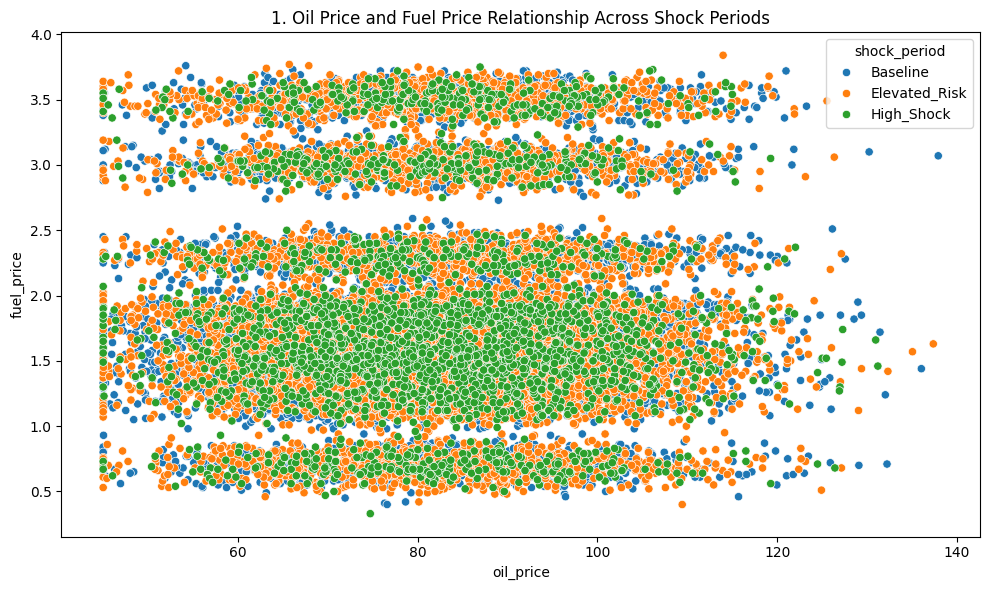

In [13]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='oil_price', y='fuel_price', hue='shock_period')
plt.title(f'{plot_no}. Oil Price and Fuel Price Relationship Across Shock Periods')
show_fig()
plot_no += 1

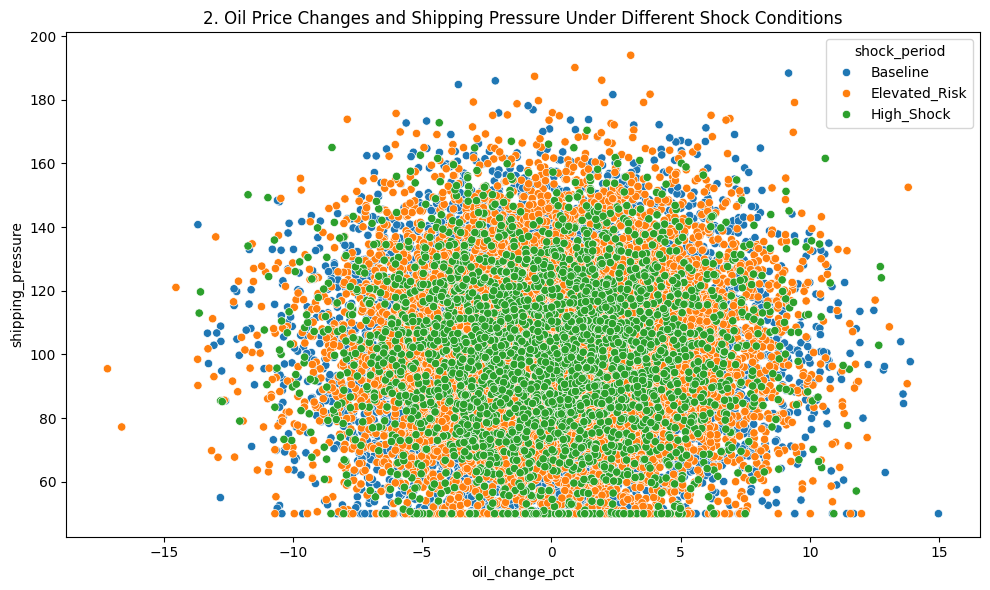

In [14]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='oil_change_pct', y='shipping_pressure', hue='shock_period')
plt.title(f'{plot_no}. Oil Price Changes and Shipping Pressure Under Different Shock Conditions')
show_fig()
plot_no += 1

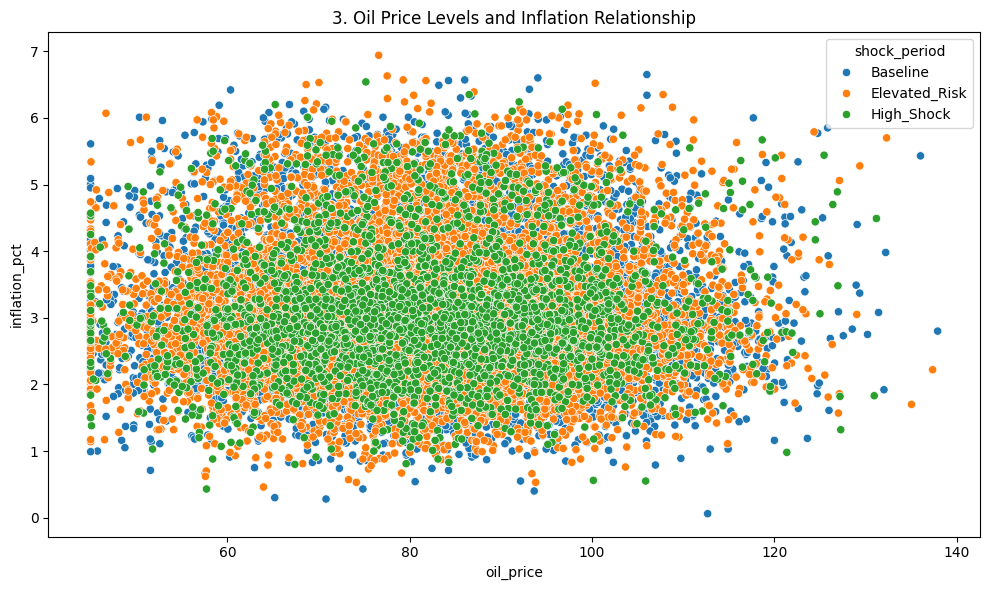

In [15]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='oil_price', y='inflation_pct', hue='shock_period')
plt.title(f'{plot_no}. Oil Price Levels and Inflation Relationship')
show_fig()
plot_no += 1

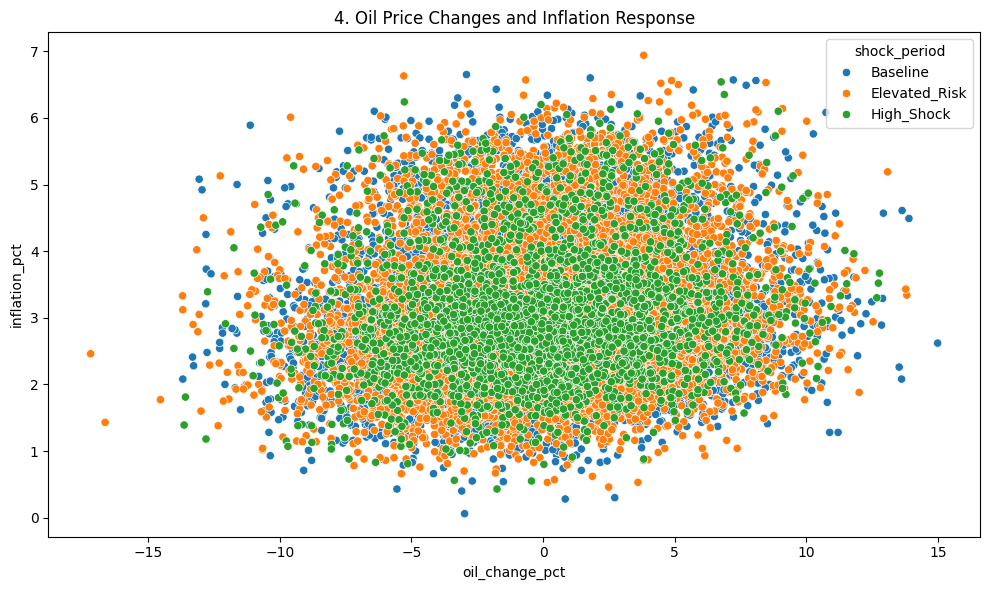

In [16]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='oil_change_pct', y='inflation_pct', hue='shock_period')
plt.title(f'{plot_no}. Oil Price Changes and Inflation Response')
show_fig()
plot_no += 1

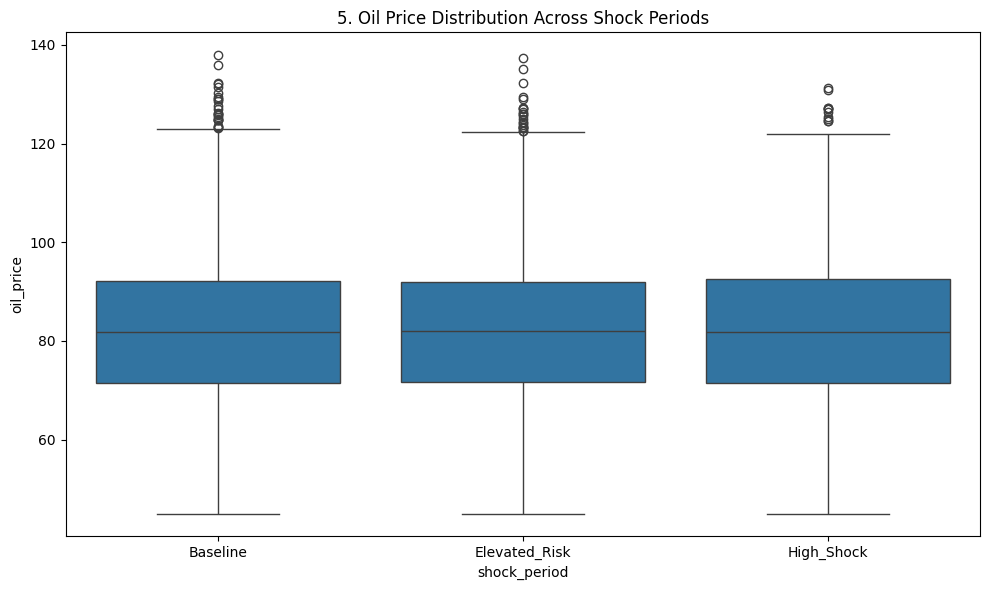

In [17]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='shock_period', y='oil_price')
plt.title(f'{plot_no}. Oil Price Distribution Across Shock Periods')
show_fig()
plot_no += 1

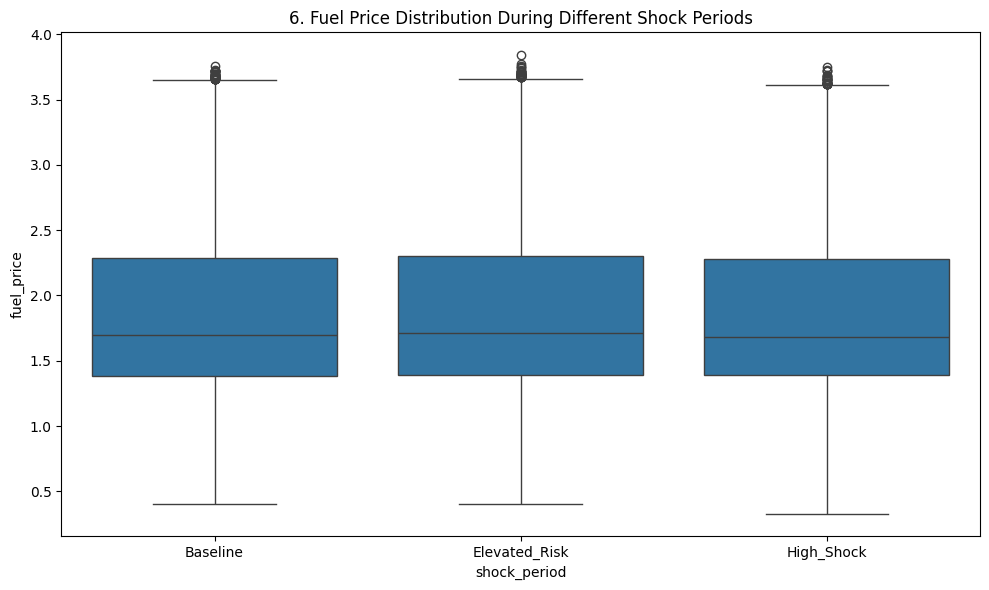

In [18]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='shock_period', y='fuel_price')
plt.title(f'{plot_no}. Fuel Price Distribution During Different Shock Periods')
show_fig()
plot_no += 1

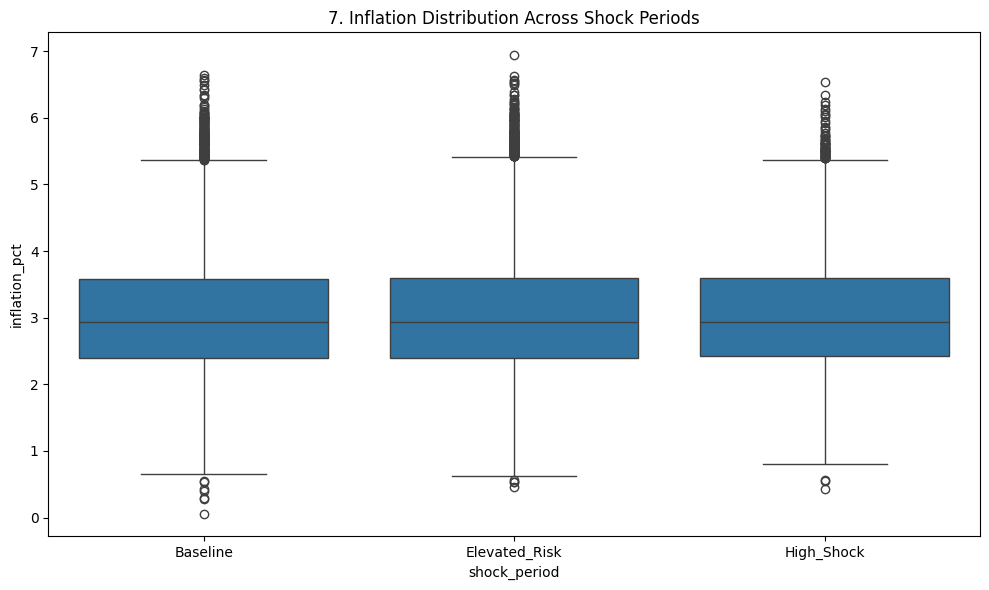

In [19]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='shock_period', y='inflation_pct')
plt.title(f'{plot_no}. Inflation Distribution Across Shock Periods')
show_fig()
plot_no += 1

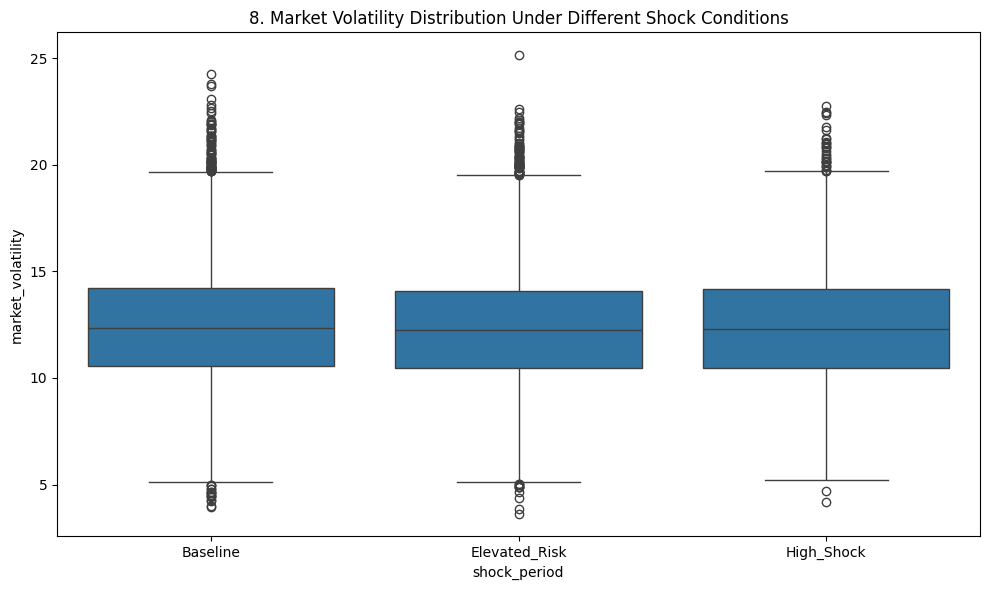

In [20]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='shock_period', y='market_volatility')
plt.title(f'{plot_no}. Market Volatility Distribution Under Different Shock Conditions')
show_fig()
plot_no += 1

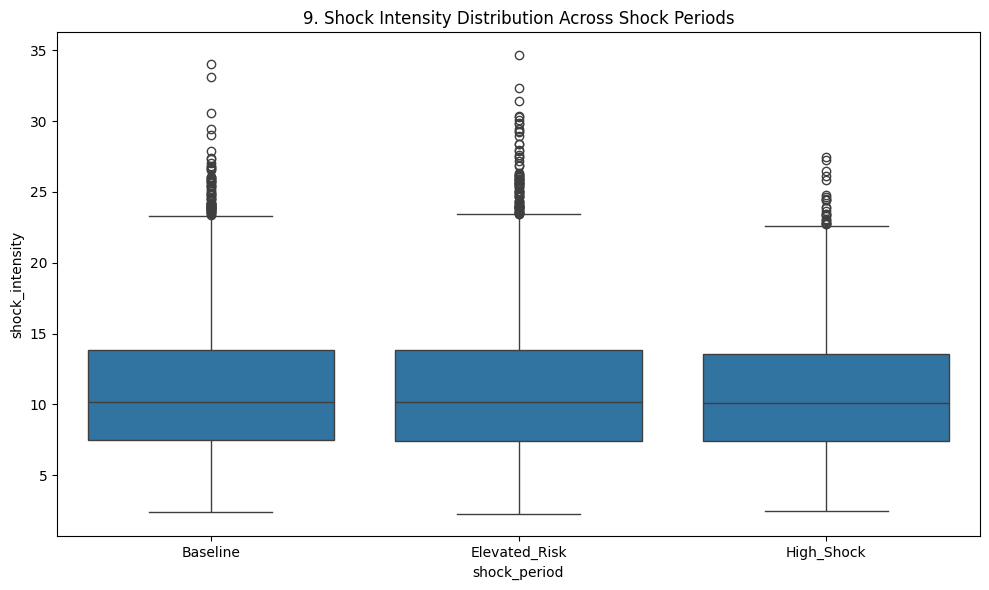

In [21]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='shock_period', y='shock_intensity')
plt.title(f'{plot_no}. Shock Intensity Distribution Across Shock Periods')
show_fig()
plot_no += 1

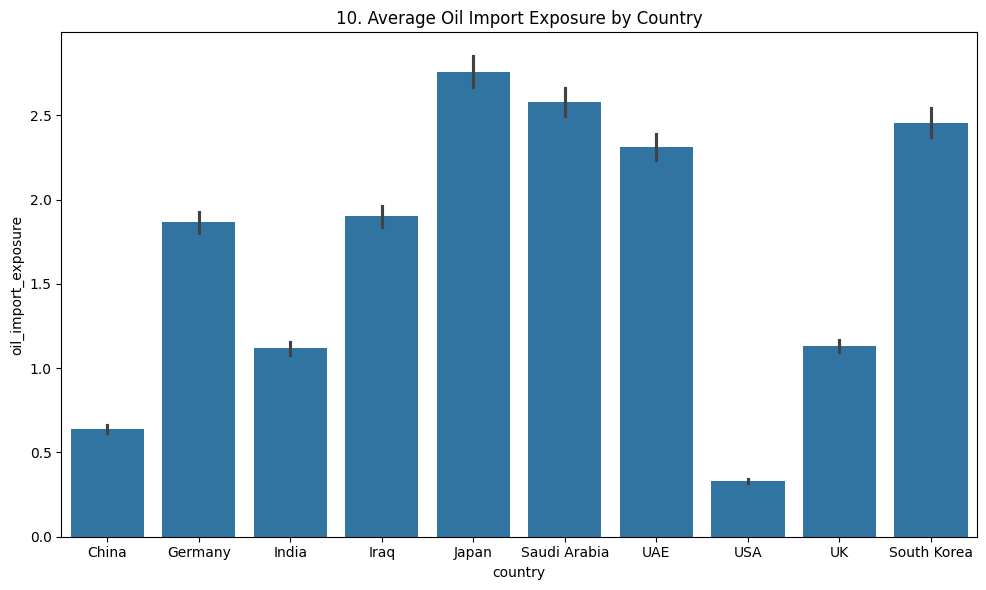

In [22]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='country', y='oil_import_exposure', estimator='mean')
plt.title(f'{plot_no}. Average Oil Import Exposure by Country')
show_fig()
plot_no += 1

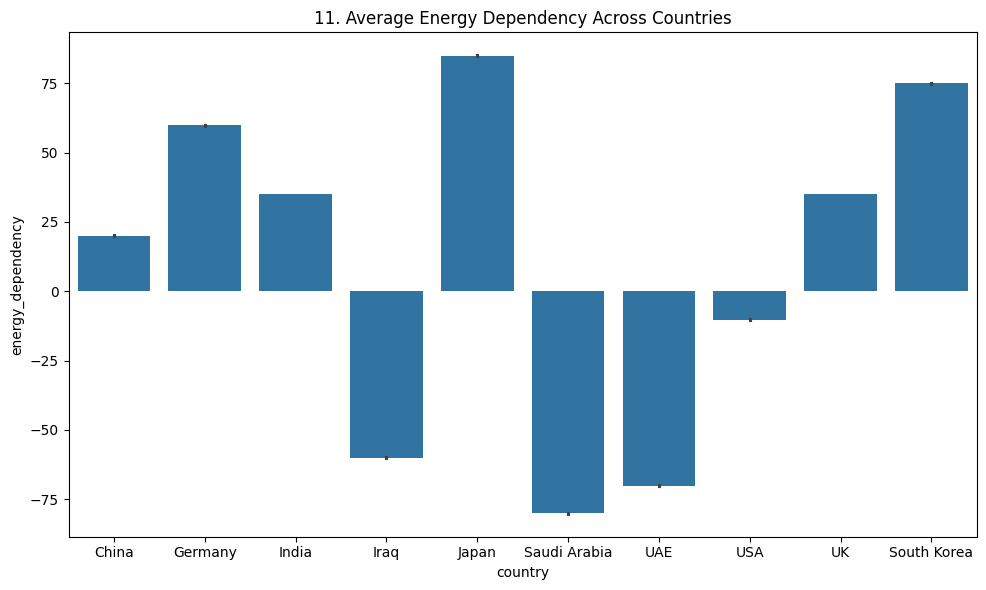

In [23]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='country', y='energy_dependency', estimator='mean')
plt.title(f'{plot_no}. Average Energy Dependency Across Countries')
show_fig()
plot_no += 1

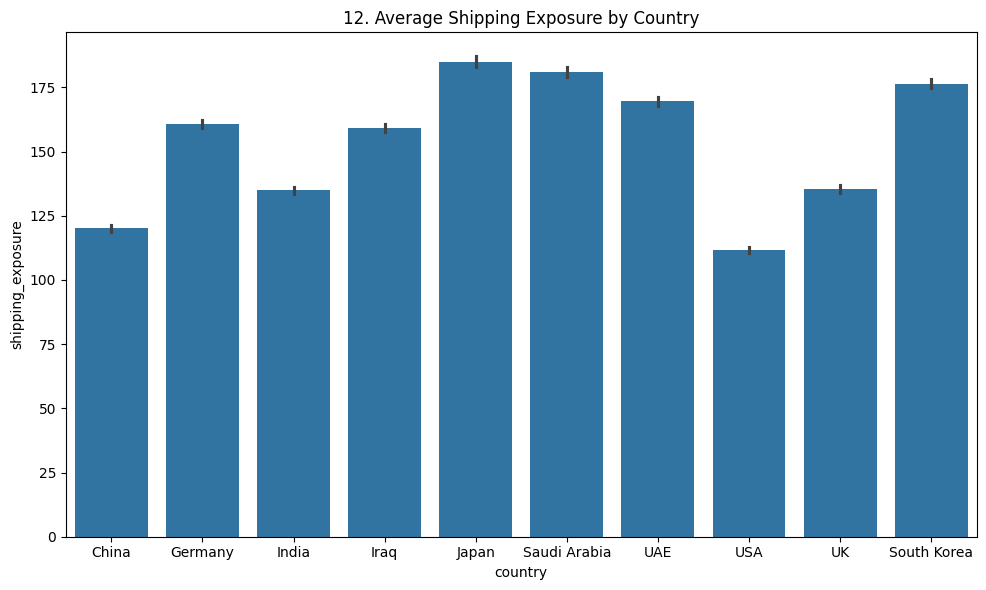

In [24]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='country', y='shipping_exposure', estimator='mean')
plt.title(f'{plot_no}. Average Shipping Exposure by Country')
show_fig()
plot_no += 1

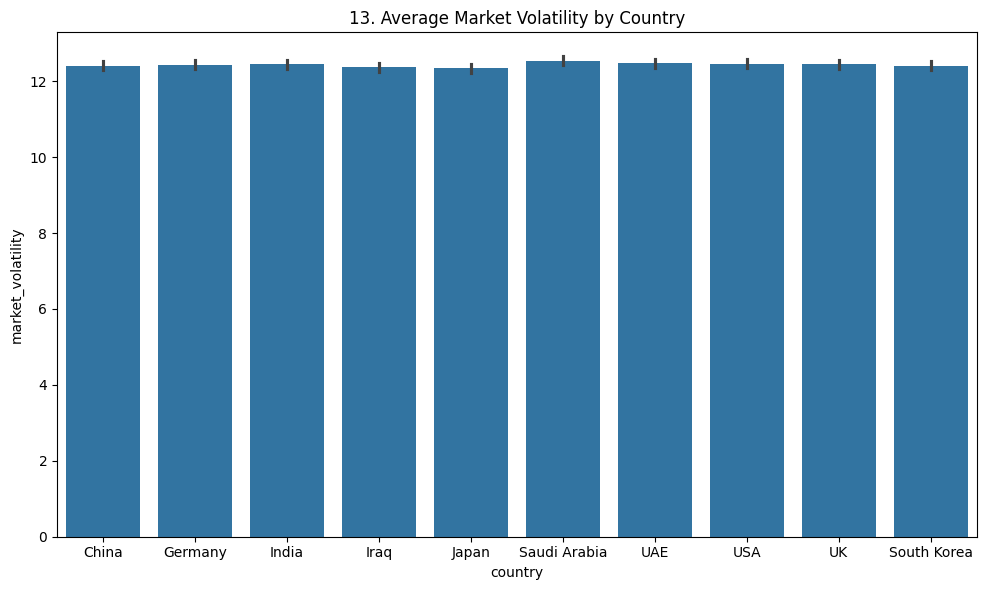

In [25]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='country', y='market_volatility', estimator='mean')
plt.title(f'{plot_no}. Average Market Volatility by Country')
show_fig()
plot_no += 1

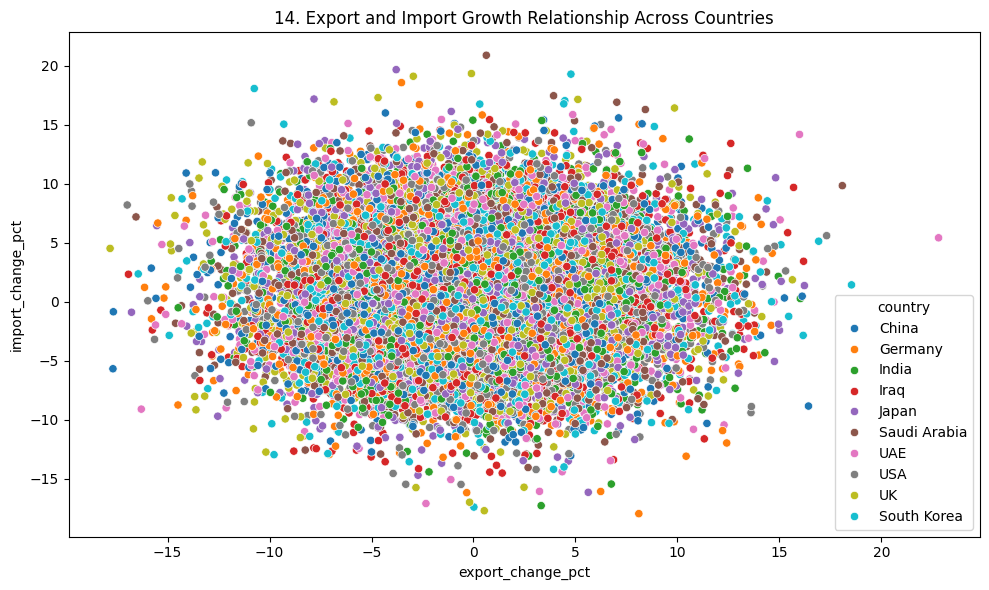

In [26]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='export_change_pct', y='import_change_pct', hue='country')
plt.title(f'{plot_no}. Export and Import Growth Relationship Across Countries')
show_fig()
plot_no += 1

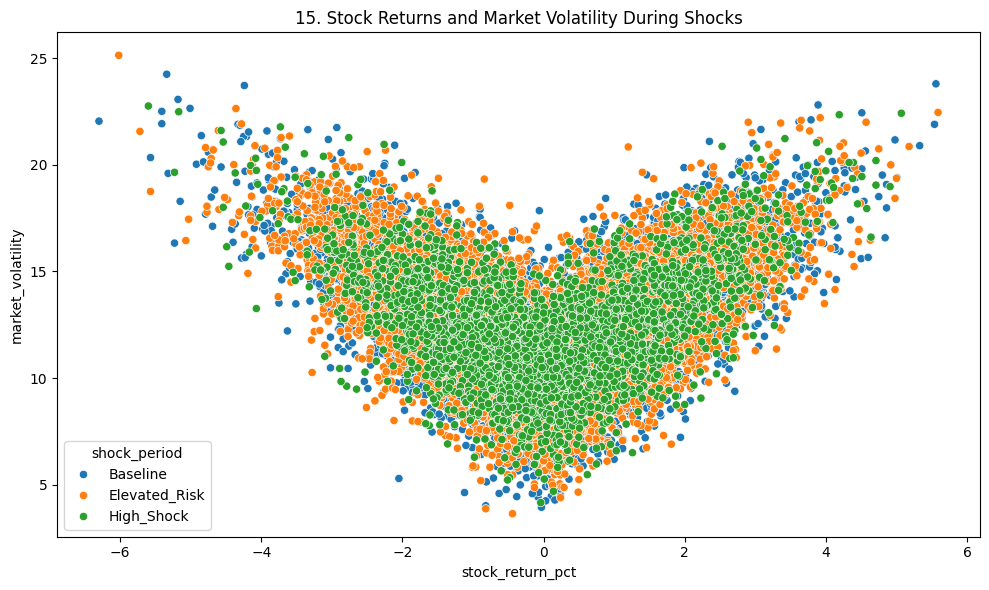

In [27]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='stock_return_pct', y='market_volatility', hue='shock_period')
plt.title(f'{plot_no}. Stock Returns and Market Volatility During Shocks')
show_fig()
plot_no += 1

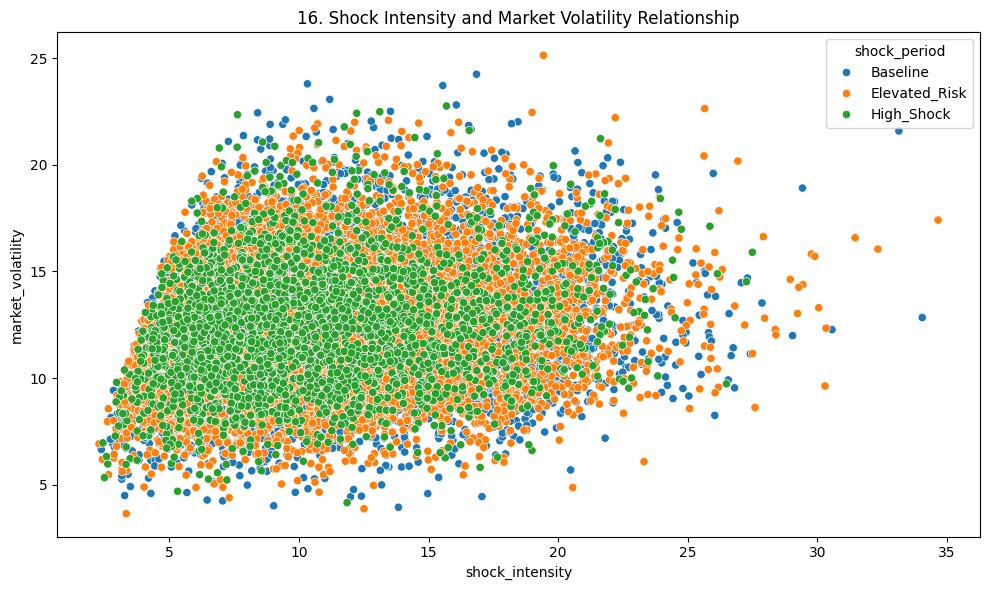

In [28]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='shock_intensity', y='market_volatility', hue='shock_period')
plt.title(f'{plot_no}. Shock Intensity and Market Volatility Relationship')
show_fig()
plot_no += 1

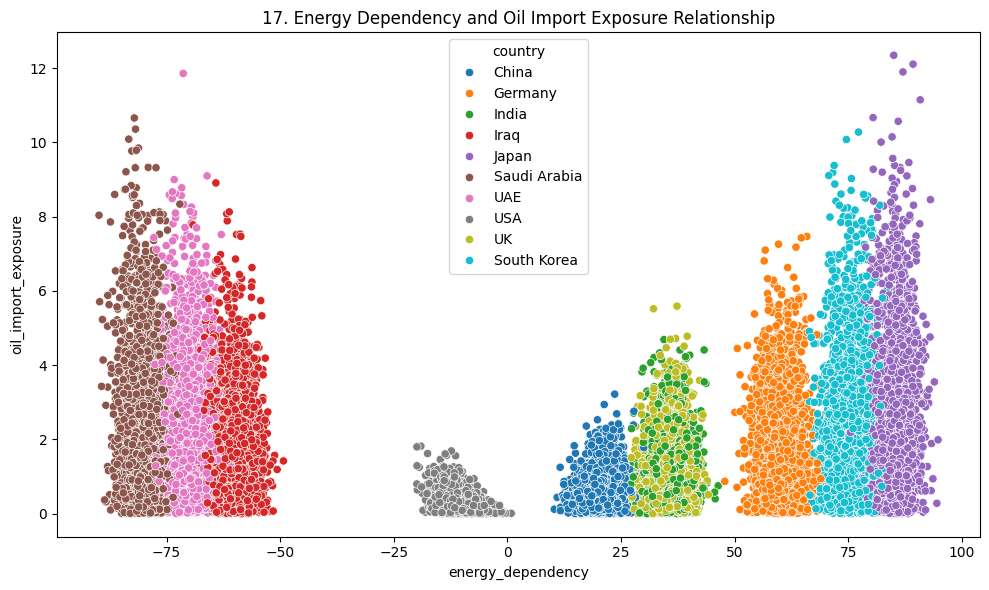

In [29]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='energy_dependency', y='oil_import_exposure', hue='country')
plt.title(f'{plot_no}. Energy Dependency and Oil Import Exposure Relationship')
show_fig()
plot_no += 1

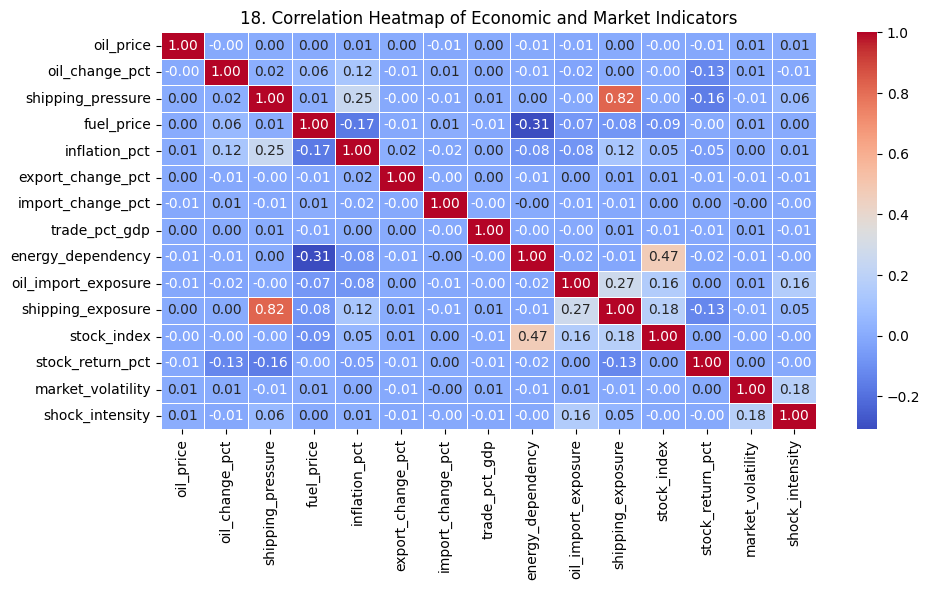

In [30]:
fig = plt.figure(figsize=(10,6))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title(f'{plot_no}. Correlation Heatmap of Economic and Market Indicators')
show_fig()
plot_no += 1

# Model Training

## Select market volatility as the regression target

In [31]:
X = df.drop(columns=['market_volatility', 'date'], errors='ignore')
y = df['market_volatility']

categorical_cols = X.select_dtypes(include=['object', 'category']).columns
numeric_cols = X.select_dtypes(include='number').columns

## Prepare numerical and categorical features

In [32]:
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), categorical_cols)
])

## Build a regularized gradient boosting regression model

In [33]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.04,
        max_leaf_nodes=15,
        min_samples_leaf=20,
        l2_regularization=2.0,
        random_state=42
    ))
])

## Split the dataset into training and testing sets

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## Train the model

In [35]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Generate predictions

In [36]:
y_pred = model.predict(X_test)

## Evaluate regression performance

In [37]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("Model:", model.named_steps['regressor'])
print("R² Score:", round(r2, 4))
print("R² Score (%):", round(r2 * 100, 2))
print("Mean Absolute Error:", round(mae, 4))

Model: HistGradientBoostingRegressor(l2_regularization=2.0, learning_rate=0.04,
                              max_iter=300, max_leaf_nodes=15, random_state=42)
R² Score: 0.7348
R² Score (%): 73.48
Mean Absolute Error: 1.1126


## Plot actual versus predicted values

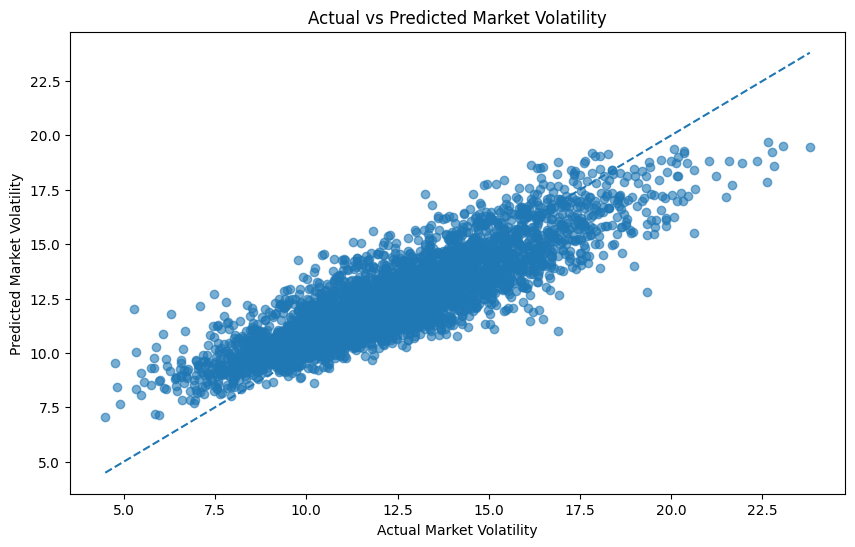

In [38]:
fig = plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Market Volatility")
plt.ylabel("Predicted Market Volatility")
plt.title("Actual vs Predicted Market Volatility")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)
plt.show()